In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Load database

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_parquet('../../develop/database/final_hospital_database.parquet')
df.head(1)

,patient_id,name,age,arrival_date,departure_date,service,satisfaction,month,week,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,total_staff,staff_present,staff_absens,length_of_stay
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61,3,3,27,66.0,27.0,39.0,63.0,72.0,25,0.0,25.0,6


In [3]:
df['length_of_stay'].describe()

count    10000.000000
mean         7.488100
std          4.003856
min          1.000000
25%          4.000000
50%          7.000000
75%         11.000000
max         14.000000
Name: length_of_stay, dtype: float64

## Feature engineering

In [4]:
df['patient_churn'] = (df['satisfaction'] <= 70) & (df['length_of_stay'] <= 4) | (df["patients_refused"] > df["patients_admitted"])

In [8]:
# Apply for lambda x: true = 1, false = 0
df['patient_churn'] = df['patient_churn'].apply(lambda x: 1 if x else 0)

In [10]:
df.to_parquet('../../develop/database/fix_final_hospital_database.parquet', index=False)

In [186]:
df.head(3)
print(f"Data: {df['patient_churn'].value_counts()}")

Data: patient_churn
True     6028
False    3972
Name: count, dtype: int64


## Label encoder

In [187]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

# Encode categorical variables
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [188]:
df_encoded.head(3)

,patient_id,name,age,arrival_date,departure_date,service,satisfaction,month,week,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,total_staff,staff_present,staff_absens,length_of_stay,patient_churn
0,378,7537,24,2025-03-16,2025-03-22,3,61,3,3,27,66.0,27.0,39.0,63.0,72.0,25,0.0,25.0,6,True
1,9394,8153,6,2025-12-13,2025-12-14,3,83,12,2,40,26.0,26.0,0.0,96.0,56.0,25,23.0,2.0,1,False
2,6737,4755,24,2025-06-29,2025-07-05,2,83,6,5,40,103.0,40.0,63.0,73.0,52.0,28,23.0,5.0,6,True


## Split data into X and y

In [189]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['arrival_date', 'departure_date', 'patient_churn', 'name'])
y = df_encoded['patient_churn']

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{y_train.value_counts(normalize=True)}")

Training set size: 8000 samples
Testing set size: 2000 samples
Training set class distribution:
patient_churn
True     0.60275
False    0.39725
Name: proportion, dtype: float64


## Machine learning method

In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

# Define models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Hypermarameter grids for each model
param_grid = {
    'RandomForestClassifier': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    'DecisionTreeClassifier': {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    'LogisticRegression': {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    },
    'XGBClassifier': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    'GradientBoostingClassifier': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

# Train and evaluate each model
def train_and_evaluate_model(model_name, model, param_grid):
    print("\n" + "="*70)
    print(f"Training {model_name}...")
    print("="*70)

    # Hyperparameter tuning using RandomizedSearchCV
    random_search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1, verbose=1)
    random_search.fit(X_train, y_train)

    # Get the best model
    best_model = random_search.best_estimator_

    # Get the best hyperparameters
    best_params = random_search.best_params_

    print("\nBest parameters:")
    print(best_params)

    # Make predictions on the test set
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Print the evaluation metrics
    for metric_name, metric_value in zip(['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'], [accuracy, precision, recall, f1, roc_auc]):
        print(f"{metric_name}: {metric_value:.4f}")

    # Print the classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Print the confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # ROC Curev
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    return (best_model, best_params,{
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    })

In [191]:
# Execute the training and evaluation for each model
best_models = {}
results = []

for model_name, model in models.items():
    best_model, best_params, metrics = train_and_evaluate_model(model_name, model, param_grid[model.__class__.__name__])

    best_models[model_name] = {
        'model': best_model,
        'best_params': best_params,
        'metrics': metrics
    }

    # Store the results on appending
    results.append({
        'model': model_name,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'roc_auc': metrics['roc_auc']
    })

# Results DataFrame
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
print("\nModel Comparison Results:")
results_df


Training Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}
Accuracy: 0.9890
Precision: 0.9933
Recall: 0.9884
F1 Score: 0.9909
ROC AUC: 0.9995

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.99      0.99       794
        True       0.99      0.99      0.99      1206

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[ 786    8]
 [  14 1192]]

Training Decision Tree...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best parameters:
{'min_samples_split': 2, 'max_depth': None}
Accuracy: 0.9835
Precision: 0.9867
Recall: 0.9859
F1 Score: 0.9863
ROC AUC: 0.9829

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.98      0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma


Best parameters:
{'solver': 'liblinear', 'C': 1}
Accuracy: 0.9630
Precision: 0.9788
Recall: 0.9594
F1 Score: 0.9690
ROC AUC: 0.9892

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.97      0.95       794
        True       0.98      0.96      0.97      1206

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000


Confusion Matrix:
[[ 769   25]
 [  49 1157]]

Training XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:15:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:15:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:15:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:15:47] WARNING: /Users/runner/work/xgboost/xgboost/src


Best parameters:
{'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2}
Accuracy: 0.9960
Precision: 0.9975
Recall: 0.9959
F1 Score: 0.9967
ROC AUC: 0.9999

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       794
        True       1.00      1.00      1.00      1206

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:
[[ 791    3]
 [   5 1201]]

Training Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters:
{'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Accuracy: 0.9940
Precision: 0.9958
Recall: 0.9942
F1 Score: 0.9950
ROC AUC: 0.9998

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       794
        True       1.00      0.99      1.00      1206

 

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.9960,0.997508,0.995854,0.996680,0.999933
1,Gradient Boosting,0.9940,0.995847,0.994196,0.995021,0.999810
2,Random Forest,0.9890,0.993333,0.988391,0.990856,0.999503
3,Decision Tree,0.9835,0.986722,0.985904,0.986313,0.982876
4,Logistic Regression,0.9630,0.978849,0.959370,0.969012,0.989213


## Check class balance dataset (Data skewed checking)

In [192]:
print("Patient churn distribution in the dataset:")
print(df['patient_churn'].value_counts(normalize=True))

print("\nPatient churn percentage:")
print(df['patient_churn'].value_counts(normalize=True).mul(100).round(2))


Patient churn distribution in the dataset:
patient_churn
True     0.6028
False    0.3972
Name: proportion, dtype: float64

Patient churn percentage:
patient_churn
True     60.28
False    39.72
Name: proportion, dtype: float64


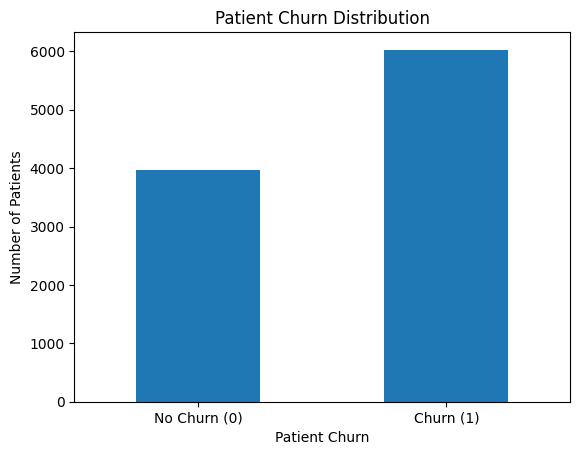

In [193]:
import matplotlib.pyplot as plt

df['patient_churn'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Patient Churn')
plt.ylabel('Number of Patients')
plt.title('Patient Churn Distribution')
plt.xticks([0, 1], ['No Churn (0)', 'Churn (1)'], rotation=0)
plt.show()